In [1]:
import torch
from torchvision import datasets,transforms
from torch.utils.data import Subset,DataLoader,Dataset
from torch import nn
import matplotlib.pyplot as plt

In [2]:
train_samples=10000
test_samples=1000
batch_size=100
device=torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [3]:

dataset=datasets.CIFAR10(root="./",train=True,transform=transforms.ToTensor(),download=False)
train_dataset=Subset(dataset=dataset,indices=range(train_samples))
test_dataset=Subset(dataset=dataset,indices=range(train_samples,train_samples+test_samples))
train_dataloader=DataLoader(train_dataset,batch_size,pin_memory=True)
test_dataloader=DataLoader(test_dataset,batch_size,pin_memory=True)

c:\Users\MAGIC\Desktop\deep_learning_Studies\env\Lib\site-packages\torchvision\datasets\cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


torch.Size([3, 32, 32])


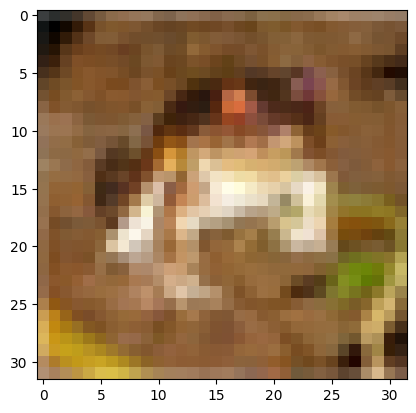

In [4]:
print(dataset[0][0].shape)
plt.imshow(dataset[0][0].permute(1,2,0))
plt.show()

In [5]:
class CNN_model(nn.Module):
    def __init__(self):
        super().__init__()
        # [3, 32, 32]
        self.conv1=nn.Conv2d(3,6,3,padding=1)
        self.conv2=nn.Conv2d(6,12,3)
        self.relu=nn.ReLU()
        self.pool=nn.MaxPool2d(2,2)
        self.fc1=nn.Linear(12*7*7,128)
        self.fc2=nn.Linear(128,10)
    def forward(self,x):
        x=self.pool(self.relu(self.conv1(x)))
        x=self.pool(self.relu(self.conv2(x)))
        x=x.reshape(x.shape[0],-1)
        x=self.relu(self.fc1(x))
        x=self.fc2(x)
        return x
model=CNN_model().to(device=device)
# optimizer=torch.optim.Adam(model.parameters())
# criterion=nn.CrossEntropyLoss()


In [20]:
def train_model(model,train_dataloader,test_dataloader,optimizer,criterion,epoch_num):
    LOSS_train=[]
    LOSS_test=[]
    AC=[]
    scheduler=torch.optim.lr_scheduler.StepLR(optimizer=optimizer,step_size=1,gamma=0.5)
    for epoch in range(epoch_num):
        L=0
        LT=0
        for x,y in train_dataloader:
            x=x.to(device)
            y=y.to(device)
            y_hat=model(x)
            loss=criterion(y_hat,y)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            L+=loss.item()
        scheduler.step()
        correct_num=0
        with torch.no_grad():
            for x,y in test_dataloader:
                x=x.to(device)
                y=y.to(device)
                y_hat=model(x)
                loss=criterion(y_hat,y)
                LT+=loss.item()
                y_hat=torch.argmax(y_hat,dim=1)

                correct_num+=torch.sum(y_hat==y).item()
        L/=len(train_dataloader)
        LT/=len(test_dataloader)
        accuracy=correct_num/test_samples
        LOSS_train.append(L)
        LOSS_test.append(LT)
        AC.append(accuracy)
        print(f"epoch:{epoch}, Loss:{L} t_Loss:{LT} accuracy:{accuracy} learning rate:{optimizer.param_groups[0]['lr']}")
    

In [7]:
# plt.plot(range(epoch_num),LOSS_train,label="train_loss")
# plt.plot(range(epoch_num),LOSS_test,label="test_loss")
# plt.plot(range(epoch_num),AC,label="accuracy")
# plt.legend()
# plt.show()

In [8]:
def show(model,test_dataloader):
    import matplotlib.pyplot as plt
    reflet_types=["airplane","automobile","bird","cat","deer","dog","frog","horse","ship","truck"]
    for x,y in test_dataloader:
        x=x.to(device)
        y_hat=model(x)
        print(y_hat.shape)
        y_hat=torch.argmax(y_hat,dim=1)
        for i in range(10):
            plt.subplot(2,5,i+1)
            plt.imshow(x[i].cpu().permute(1,2,0))
            print((reflet_types[y[i].item()],reflet_types[y_hat[i].item()]))
        print(f"num of samples:{x.cpu().shape[0]},correct num:{sum(y==y_hat.cpu())},accuracy:{(sum(y==y_hat.cpu())/x.cpu().shape[0]):.3f}")
        break
    plt.show()

In [9]:
x=0
for name,para in model.named_parameters():
    print(name,para.shape)
print(x)

conv1.weight torch.Size([6, 3, 3, 3])
conv1.bias torch.Size([6])
conv2.weight torch.Size([12, 6, 3, 3])
conv2.bias torch.Size([12])
fc1.weight torch.Size([128, 588])
fc1.bias torch.Size([128])
fc2.weight torch.Size([10, 128])
fc2.bias torch.Size([10])
0


In [10]:
#transfer learning


import torchvision.models as models

tmodel =models.resnet18(pretrained=True)
tmodel.fc=nn.Linear(tmodel.fc.in_features,10)
tmodel=tmodel.to(device=device)
print(tmodel)


ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_sta

c:\Users\MAGIC\Desktop\deep_learning_Studies\env\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
c:\Users\MAGIC\Desktop\deep_learning_Studies\env\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


In [18]:

correct_num=0
print(test_dataset[0][0].shape)

with torch.no_grad():
    for x,y in test_dataloader:
        x=x.to(device)
        y=y.to(device)
        y_hat=tmodel(x)
        y_hat=torch.argmax(y_hat,dim=1)
        correct_num+=torch.sum(y_hat==y).item()

accuracy=correct_num/test_samples
print(accuracy)

torch.Size([3, 224, 224])
0.795


In [12]:
dataset=datasets.CIFAR10(root="./",train=True,transform=transforms.Compose([transforms.Resize((224,224)),transforms.ToTensor()]),download=False)
train_dataset=Subset(dataset=dataset,indices=range(train_samples))
test_dataset=Subset(dataset=dataset,indices=range(train_samples,train_samples+test_samples))
train_dataloader=DataLoader(train_dataset,batch_size,pin_memory=True)
test_dataloader=DataLoader(test_dataset,batch_size,pin_memory=True)
print(train_dataset[0][0])

tensor([[[0.2314, 0.2314, 0.2314,  ..., 0.5804, 0.5804, 0.5804],
         [0.2314, 0.2314, 0.2314,  ..., 0.5804, 0.5804, 0.5804],
         [0.2314, 0.2314, 0.2314,  ..., 0.5804, 0.5804, 0.5804],
         ...,
         [0.6941, 0.6941, 0.6941,  ..., 0.4824, 0.4824, 0.4824],
         [0.6941, 0.6941, 0.6941,  ..., 0.4824, 0.4824, 0.4824],
         [0.6941, 0.6941, 0.6941,  ..., 0.4824, 0.4824, 0.4824]],

        [[0.2431, 0.2431, 0.2431,  ..., 0.4863, 0.4863, 0.4863],
         [0.2431, 0.2431, 0.2431,  ..., 0.4863, 0.4863, 0.4863],
         [0.2431, 0.2431, 0.2431,  ..., 0.4863, 0.4863, 0.4863],
         ...,
         [0.5647, 0.5647, 0.5647,  ..., 0.3608, 0.3608, 0.3608],
         [0.5647, 0.5647, 0.5647,  ..., 0.3608, 0.3608, 0.3608],
         [0.5647, 0.5647, 0.5647,  ..., 0.3608, 0.3608, 0.3608]],

        [[0.2471, 0.2471, 0.2471,  ..., 0.4039, 0.4039, 0.4039],
         [0.2471, 0.2471, 0.2471,  ..., 0.4039, 0.4039, 0.4039],
         [0.2471, 0.2471, 0.2471,  ..., 0.4039, 0.4039, 0.

In [22]:
train_model(tmodel,train_dataloader,test_dataloader,torch.optim.Adam(tmodel.parameters()),nn.CrossEntropyLoss(),3)

epoch:0, Loss:0.24870216257870198 t_Loss:0.6161541283130646 accuracy:0.811 learning rate:0.0005
epoch:1, Loss:0.08081352511420846 t_Loss:0.45009566843509674 accuracy:0.863 learning rate:0.00025
epoch:2, Loss:0.011450799282174557 t_Loss:0.4357656419277191 accuracy:0.87 learning rate:0.000125


torch.Size([100, 10])
('automobile', 'automobile')
('frog', 'frog')
('frog', 'frog')
('ship', 'frog')
('ship', 'ship')
('cat', 'cat')
('deer', 'deer')
('frog', 'frog')
('airplane', 'airplane')
('frog', 'bird')
num of samples:100,correct num:85,accuracy:0.850


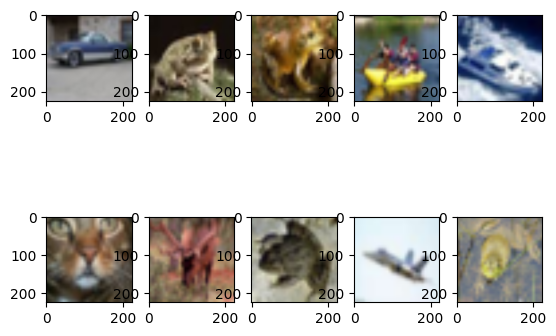

In [14]:
show(tmodel,test_dataloader)

In [15]:

# torch.save({"state_dict":tmodel.state_dict()},"model.ckpt")

torch.Size([100, 10])
('automobile', 'automobile')
('frog', 'cat')
('frog', 'frog')
('ship', 'frog')
('ship', 'ship')
('cat', 'cat')
('deer', 'deer')
('frog', 'frog')
('airplane', 'airplane')
('frog', 'cat')
num of samples:100,correct num:83,accuracy:0.830


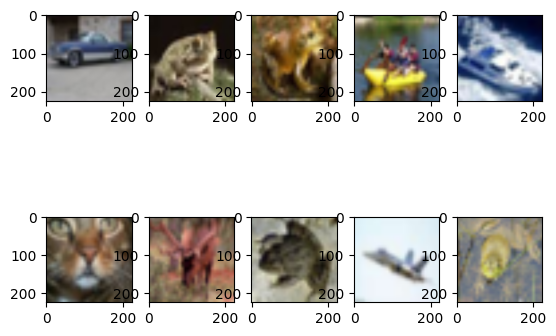

In [26]:
model=models.resnet18()
model.fc=nn.Linear(model.fc.in_features,10)
model.load_state_dict(torch.load("model.ckpt")['state_dict'])
model=model.to(device=device)
show(model,test_dataloader)